# LOFAR single station imaging

Based on version 1.4 of V.A. Moss's tutorial, tutorial from M.A. Brentjens 8/8/2017.

Updated February 2020 by T.J. Dijkema with aerial imagery backdrops.

This notebook is intended to explore the imaging of one XST file. To do all of the things in this notebook for a batch of XST files, have a look at the function `make_xst_plots` (`from lofarimaging import make_xst_plots`).

In [90]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [91]:
import os
import sys 

import ilisa
import dreambeam

In [92]:
import time
import datetime
import glob
import numpy as np

from lofarantpos.db import LofarAntennaDatabase

In [93]:
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import ListedColormap, Normalize
import warnings
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.axes as maxes
from matplotlib.ticker import FormatStrFormatter
import re

In [94]:
from astropy.coordinates import SkyCoord, GCRS, EarthLocation, AltAz, SkyOffsetFrame, CartesianRepresentation, get_sun, get_body
import astropy.units as u
from astropy.time import Time

In [95]:
# We need lofarantpos >= 0.4.0 to get the station rotations

from packaging import version
import lofarantpos
assert(version.parse(lofarantpos.__version__) >= version.parse("0.4.0"))

In [96]:
#%pip install opencv-python

In [97]:
from lofarimaging import find_caltable, sb_from_freq, freq_from_sb, read_caltable, \
    read_acm_cube, get_map, sky_imager, ground_imager, get_station_pqr, get_station_type, \
    skycoord_to_lmn, nearfield_imager, make_leaflet_map, make_sky_plot, make_ground_plot, \
    apply_calibration, get_full_station_name, get_station_xyz

In [98]:
# We need python 3.6 for f-string formatting

assert(sys.version_info.major + 0.1*sys.version_info.minor >= 3.6)

In [99]:
# Define directories 
data_dir = "./test"
caltable_dir = "./test/CalTables"  # Root directory under which station information is stored in subdirectories DE602C/etc/, RS106/etc/, ...

In [100]:
# Define area of interest: square of side = 500km
# I had to make this square bigger because at this very high altitude, a smaller section will be too detailed
# before it was 150m ?????????????????????????????????????????
extent = [-500000, 500000, -500000, 500000] # size and physical limits of the "projection" from LOFAR in meters
pixels_per_metre = 0.0002
height = 550e3 #~550e3 height of Starlink satellites

In [101]:
os.makedirs('results', exist_ok=True)

In [102]:
start1 = time.time()

In [103]:
# Read all available .dat files
# CHANGE TO 2024 FILE they last more than 1sec ????????
print(f"Searching for available files in {data_dir}")
files = glob.glob(data_dir + "/*.dat")
for file_index, filename in enumerate(files):
    print(f"{file_index}: {filename}")

Searching for available files in ./test
0: ./test/20230111_072042_xst.dat
1: ./test/20241106_202204_xst.dat
2: ./test/20241106_212920_xst.dat
3: ./test/20250329_075018_xst.dat
4: ./test/20250329_091411_xst.dat
5: ./test/20250329_092932_xst.dat


In [104]:
# Select a file
xst_filename = files[5]

print("File selected:", xst_filename)

File selected: ./test/20250329_092932_xst.dat


In [105]:
station_name = "LV614"

# RCU Mode: defines usable frequency band and filter characteristics
# rcu_mode = re.search("mode_([^_]*)", xst_filename).groups(0)[0]
rcu_mode = "3" # Hardcoded for now
# subband = int(re.search("sb([0-9]*)", xst_filename).groups(0)[0])
subband = 167 #Hardcoded for now too (using Iñaki's file bc the ones from 2024 had multiple subbands & idk what to do)

# Read subband from .h file

# import re

# Assuming h_filename is already defined
# h_filename = xst_filename.replace(".dat", ".h")

# Read the .h file
# with open(h_filename, 'r') as file:
#    content = file.read()

# Find the subband number using regex
# match = re.search(r'--xcsubband=(\d+)', content)
# if match:
#    subband = int(match.group(1))
# else:
#    subband = None  # or handle the case where the subband is not found

# print("Subband: ", subband)

obsdatestr, obstimestr, *_ = os.path.basename(xst_filename).rstrip(".dat").split("_")

In [106]:
rcu_mode = rcu_mode.replace("sparseeven", "sparse_even").replace("sparseodd", "sparse_odd")

In [107]:
station_type = get_station_type(station_name)

In [108]:
station_name = get_full_station_name(station_name, rcu_mode)

# Get the data
fname = f"{obsdatestr}_{obstimestr}_{station_name}_SB{subband}"

npix_l, npix_m = 131, 131
freq = freq_from_sb(subband, rcu_mode=rcu_mode)

# Which slice in time to visualise
timestep = 0

# For ground imaging
ground_resolution = pixels_per_metre  # pixels per metre for ground_imaging, default is 0.5 pixel/metre

obstime = datetime.datetime.strptime(obsdatestr + ":" + obstimestr, '%Y%m%d:%H%M%S')
print(obstime)

# Confirm the data has been read correctly
print(f"""Station: {station_name}
Station type: {station_type}
Subband: {subband}
Timestep: {timestep}
Save title: {fname}
Sky image size: {npix_l:d} x {npix_m:d}
Ground image extent: {extent[1]-extent[0]:d} x {extent[3]-extent[2]:d} m
Ground height: {height} m\
""")

2025-03-29 09:29:32
Station: LV614LBA
Station type: intl
Subband: 167
Timestep: 0
Save title: 20250329_092932_LV614LBA_SB167
Sky image size: 131 x 131
Ground image extent: 1000000 x 1000000 m
Ground height: 550000.0 m


In [109]:
# Read AutoCorrelation Matrix cube
cube = read_acm_cube(xst_filename, station_type)

In [110]:
cube, calibration_info = apply_calibration(cube, station_name, rcu_mode, subband, caltable_dir=caltable_dir)

In [111]:
# Split into the XX and YY polarisations (RCUs)
# This needs to be modified in future for LBA sparse
cube_xx = cube[:, 0::2, 0::2]
cube_yy = cube[:, 1::2, 1::2]
visibilities_all = cube_xx + cube_yy

# Stokes I for specified timestep
visibilities = visibilities_all[timestep]
visibilities_all.shape

(602, 96, 96)

In [112]:
# Check the resulting cubes have half the size
cube_xx.shape, cube_yy.shape, visibilities.shape, visibilities.dtype

((602, 96, 96), (602, 96, 96), (96, 96), dtype('complex128'))

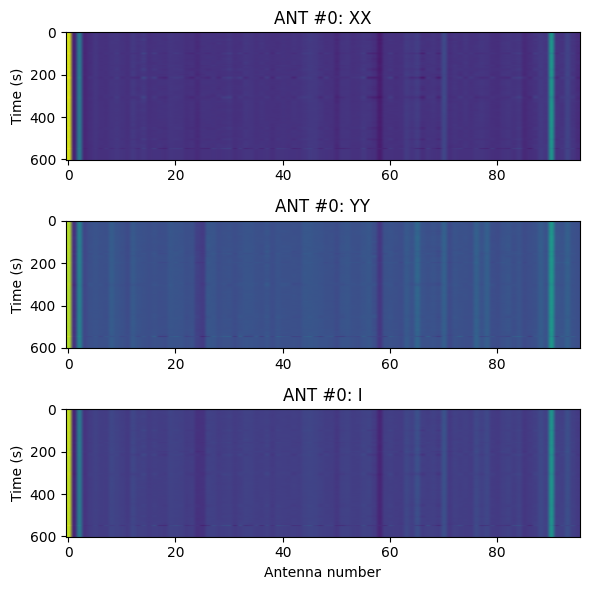

In [113]:
# Check how the various antennas/polarisation look with time
fig1, (ax0, ax1, ax2) = plt.subplots(nrows=3, ncols=1, figsize=(6,6))

ax0.imshow(cube_xx[:, 0, :].real, aspect='auto')
ax0.set_ylabel('Time (s)')
ax0.set_title('ANT #0: XX')
ax1.imshow(cube_yy[:,0,:].real,aspect='auto')
ax1.set_title('ANT #0: YY')
ax1.set_ylabel('Time (s)')
ax2.imshow(visibilities_all[:,0,:].real,aspect='auto')
ax2.set_title('ANT #0: I')
ax2.set_xlabel('Antenna number')
ax2.set_ylabel('Time (s)')
fig1.tight_layout()

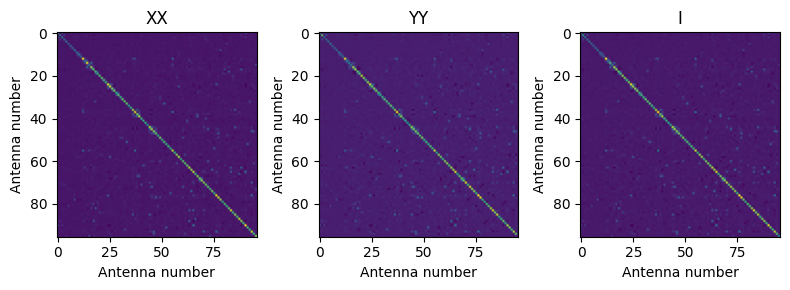

In [114]:
# Check how the correlations look
fig1, (ax0, ax1, ax2) = plt.subplots(nrows=1, ncols=3, figsize=(8,3))

ax0.imshow(cube_xx[0,:,:].real, aspect='auto')
ax0.set_xlabel('Antenna number')
ax0.set_ylabel('Antenna number')
ax0.set_title('XX')
ax1.imshow(cube_yy[0,:,:].real, aspect='auto')
ax1.set_title('YY')
ax1.set_xlabel('Antenna number')
ax1.set_ylabel('Antenna number')
ax2.imshow(visibilities.real, aspect='auto')
ax2.set_title('I')
ax2.set_xlabel('Antenna number')
ax2.set_ylabel('Antenna number')
fig1.tight_layout()

In [115]:
# Setup the database
db = LofarAntennaDatabase()

In [116]:
station_xyz, pqr_to_xyz = get_station_xyz(station_name, rcu_mode, db)

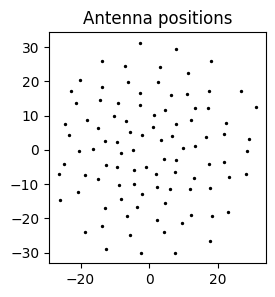

In [117]:
fig, ax = plt.subplots(figsize=(3, 3))
ax.scatter(station_xyz[:, 0], station_xyz[:, 1], s=2, facecolor='k');
ax.set_title("Antenna positions");
ax.set_aspect(1);

In [118]:
# For every antenna, calculate the distance between it and every other antenna
baselines = station_xyz[:, np.newaxis, :] - station_xyz[np.newaxis, :, :]

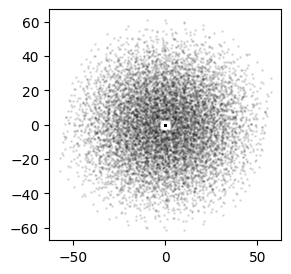

In [119]:
# Make a plot of the baselines contents (only U-V, not W)
# This gives the instantaneous U-V coverage of the LBA station
plt.figure(figsize=(3,3))
plt.scatter(baselines[:,:,0], baselines[:,:,1], facecolor='k', edgecolor='k', s=1, alpha=0.1);

In [120]:
# Account for the rotation
rotation = np.rad2deg(db.rotation_from_north(station_name))
print ('Rotation for %s: %.2f deg' % (station_name, rotation))

Rotation for LV614LBA: 12.73 deg


In [121]:
obstime_astropy = Time(obstime)
# Determine positions of Cas A and Cyg A
# Irbene station location:
station_earthlocation = EarthLocation.from_geocentric(*(db.phase_centres[station_name] * u.m))

zenith = AltAz(az=0 * u.deg, alt=90 * u.deg, obstime=obstime_astropy,
               location=station_earthlocation).transform_to(GCRS(obstime=obstime_astropy))

marked_bodies = {
    'Cas A': SkyCoord(ra=350.858*u.deg, dec=58.811*u.deg),
    'Cyg A': SkyCoord(ra=299.868*u.deg, dec=40.734*u.deg),
#        'Per A': SkyCoord.from_name("Perseus A"),
#        'Her A': SkyCoord.from_name("Hercules A"),
#        'Cen A': SkyCoord.from_name("Centaurus A"),
#        '?': SkyCoord.from_name("J101415.9+105106"),
#        '3C295': SkyCoord.from_name("3C295"),
#        'Moon': get_body('moon',obstime_astropy, location=station_earthlocation).transform_to(GCRS(obstime=obstime_astropy)),
#    'Sun': get_sun(obstime_astropy) eclipse
#        '3C196': SkyCoord.from_name("3C196")
}

############# NEW
marked_sats = {}
marked_sats_traj = {}   

from skyfield.api import wgs84, load

print(f"Lat: {station_earthlocation.lat.deg}, Lon: {station_earthlocation.lon.deg}, Alt: {station_earthlocation.height}")

# tranform astropy object to skyfield
station_location = wgs84.latlon(
    station_earthlocation.lat.deg, 
    station_earthlocation.lon.deg, 
    elevation_m=station_earthlocation.height.to(u.m).value
)

from datetime import timedelta

ts = load.timescale()
# t = ts.now()  # for real time
t = ts.utc(obstime.year, obstime.month, obstime.day, obstime.hour, obstime.minute, obstime.second)

######## for movement prediction
secs = np.arange(0, 300, 5) 
t_array = ts.utc(obstime.year, obstime.month, obstime.day, obstime.hour, obstime.minute, obstime.second + secs)

obstime_start = obstime - timedelta(days=1) # range of 1 day before observation to ensure most recent TLE at that time
start_date_str = obstime_start.strftime('%Y-%m-%d %H:%M:%S')
end_date_str = obstime.strftime('%Y-%m-%d %H:%M:%S')

from spacetrack import get_starlink_data

# load Starlink data
satellites = get_starlink_data(start_date_str, end_date_str)
# satellites = load.tle_file('https://celestrak.org/NORAD/elements/gp.php?GROUP=starlink&FORMAT=tle')

for sat in satellites:
    # relative position to Irbene
    difference = sat - station_location
    topocentric = difference.at(t) # TLE does not download the satellite's current position
                                   # but rather its orbital parameters.
                                   # It calculates the position using a mathematical model (SGP4) with .at(t)

    # obtain altitude and azimuth
    alt, az, distance = topocentric.altaz()

    # above horizon (Alt > 30)
    if alt.degrees > 30: 
        ra, dec, distance = topocentric.radec()
        # print(f"{sat.name}: Right ascension {ra.hours:.2f} h, Declination {dec.degrees:.2f}°")
        marked_sats[sat.name] = SkyCoord(ra=ra.hours*u.hourangle, dec=dec.degrees*u.deg)
        
        # save trajectory
        trajectory = difference.at(t_array)
        ra_traj, dec_traj, _ = trajectory.radec()
        marked_sats_traj[sat.name] = SkyCoord(ra=ra_traj.hours*u.hourangle, dec=dec_traj.degrees*u.deg)

marked_sats_lmn = {}
for sat_name, sat_coord in marked_sats.items():
    marked_sats_lmn[sat_name] = skycoord_to_lmn(marked_sats[sat_name], zenith)
    
marked_sats_traj_lmn = {}
for sat_name, sat_traj in marked_sats_traj.items():
    marked_sats_traj_lmn[sat_name] = skycoord_to_lmn(sat_traj, zenith)

# print(marked_sats)
# print(marked_sats_lmn)

marked_bodies_lmn = {}
for body_name, body_coord in marked_bodies.items():
    #print(body_name, body_coord.separation(zenith), body_coord.separation(zenith))
    if body_coord.transform_to(AltAz(location=station_earthlocation, obstime=obstime_astropy)).alt > 0:
        marked_bodies_lmn[body_name] = skycoord_to_lmn(marked_bodies[body_name], zenith)
        
marked_all_lmn = {**marked_bodies_lmn, **marked_sats_lmn}

Lat: 57.55688026014763, Lon: 21.85491897084111, Alt: 13.28916250819648 m
Data downloaded, converting to Skyfield objects...


In [122]:
# Fourier transform
%time img = sky_imager(visibilities, baselines, freq, npix_l, npix_m)

CPU times: user 2min 40s, sys: 1.1 s, total: 2min 41s
Wall time: 22.6 s


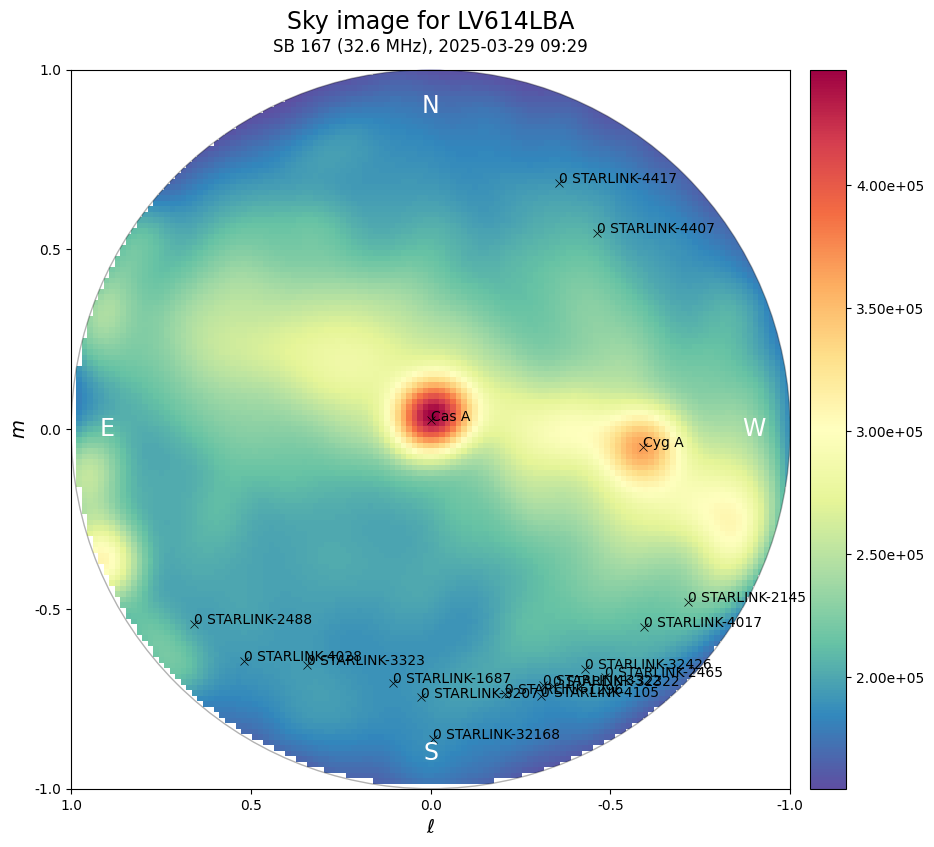

In [123]:
fig = make_sky_plot(img, marked_all_lmn, title=f"Sky image for {station_name}",
                   subtitle=f"SB {subband} ({freq / 1e6:.1f} MHz), {str(obstime)[:16]}");
##look at ilisa cal here

In [124]:
from dreambeam.telescopes.rt import load_mountedfeed
from astropy.constants import c as speed_of_light
import dreambeam.rime.jones as drj
from ilisa.antennameta.antennafieldlib import getArrayBandParams

# Station setup
stnfeed = load_mountedfeed('LOFAR', 'LV614', 'LBA', 'Hamaker')
stnrot  = stnfeed.stnRot
freqs   = np.array(stnfeed.getfreqs())

target_freq = 32.6e6
freq = freq_from_sb(subband, rcu_mode=rcu_mode)
frq_idx = np.argmin(np.abs(freqs - target_freq))
freqsel = [freqs[frq_idx]]
print(f"Closest frequency in model: {freqs[frq_idx]/1e6:.2f} MHz")

# Antenna positions
stn_pos, stn_rot, ant_pos_itrf, _ = getArrayBandParams('LV614', 'LBA')
ant_pos_itrf = np.array(ant_pos_itrf)
stn_pos      = np.array(stn_pos).flatten()
ant_pos_enu  = station_xyz
N_ant        = ant_pos_enu.shape[0]
print(f"Number of antennas: {N_ant}")

c_ms = speed_of_light.value  # 299792458.0 m/s

# Flux model (Perley & Butler 2017, LBA 30-77 MHz)
def ateam_flux(name, freq_hz):
    models = {
        'Cas A': [3.3584, -0.7518, -0.0347, -0.0705],
        'Cyg A': [3.3498, -1.0022, -0.2246,  0.0227, 0.0425],
    }
    x = np.log10(freq_hz / 1e9)
    log_S = sum(a * x**i for i, a in enumerate(models[name]))
    return 10**log_S

sources = {
    'Cas A': {'coord': marked_bodies['Cas A'], 'flux_fn': lambda f: ateam_flux('Cas A', f)},
    'Cyg A': {'coord': marked_bodies['Cyg A'], 'flux_fn': lambda f: ateam_flux('Cyg A', f)},
}

print(f"{target_freq/1e6:.1f} MHz  →  "
      f"Cas A: {ateam_flux('Cas A', target_freq):.0f} Jy  |  "
      f"Cyg A: {ateam_flux('Cyg A', target_freq):.0f} Jy")

obstime_dt = obstime_astropy.to_datetime()
obstimes   = [obstime_dt, obstime_dt + timedelta(seconds=1)]

# ── Step 1: measure empirical scale factor per source ────────────────────────
vis_noauto = visibilities.copy()
np.fill_diagonal(vis_noauto, 0)

scale_factors = {}

for name, src in sources.items():
    coord = src['coord']
    altaz = coord.transform_to(
        AltAz(obstime=obstime_astropy, location=station_earthlocation)
    )
    if altaz.alt.deg < 0:
        scale_factors[name] = None
        print(f"{name} below horizon, skipping")
        continue

    # Visibility at source direction (what sky_imager sees at that pixel)
    l_src, m_src, _ = skycoord_to_lmn(coord, zenith)
    n_src = np.sqrt(max(1 - l_src**2 - m_src**2, 0)) - 1
    phase_delays = np.exp(-2j * np.pi * freq * (
        baselines[:,:,0] * l_src +
        baselines[:,:,1] * m_src +
        baselines[:,:,2] * n_src
    ) / c_ms)
    vis_at_src = np.real(np.mean(vis_noauto * phase_delays))

    # Jones chain for this source
    ra, dec   = coord.ra.rad, coord.dec.rad
    pointingdir = (ra, dec, 'J2000')
    srcfld    = drj.DualPolFieldPointSrc(pointingdir)
    pjones    = drj.PJones(obstimes, np.transpose(stnrot), do_parallactic_rot=True)
    ejones    = stnfeed.getEJones(pointingdir, freqsel)
    J         = np.array(ejones.op(pjones.op(srcfld)).getValue()).squeeze()[0]

    S         = src['flux_fn'](freqs[frq_idx])
    B         = J @ (np.eye(2, dtype=complex) * S / 2) @ J.conj().T
    beam_scalar = float(np.real(B[0,0] + B[1,1]))

    scale_factors[name] = vis_at_src / beam_scalar
    print(f"{name}: vis_at_src={vis_at_src:.2e}  beam_scalar={beam_scalar:.2e}  "
          f"scale={scale_factors[name]:.2f}x")

# ── Step 2: subtract with empirical scale ────────────────────────────────────
visibilities_subtracted = vis_noauto.copy()

for name, src in sources.items():
    if scale_factors.get(name) is None:
        continue

    coord = src['coord']
    ra, dec     = coord.ra.rad, coord.dec.rad
    pointingdir = (ra, dec, 'J2000')
    srcfld      = drj.DualPolFieldPointSrc(pointingdir)
    pjones      = drj.PJones(obstimes, np.transpose(stnrot), do_parallactic_rot=True)
    ejones      = stnfeed.getEJones(pointingdir, freqsel)
    J           = np.array(ejones.op(pjones.op(srcfld)).getValue()).squeeze()[0]

    S           = src['flux_fn'](freqs[frq_idx])
    B           = J @ (np.eye(2, dtype=complex) * S / 2) @ J.conj().T
    beam_scalar = float(np.real(B[0,0] + B[1,1]))

    altaz  = coord.transform_to(
        AltAz(obstime=obstime_astropy, location=station_earthlocation)
    )
    az_r, el_r = altaz.az.rad, altaz.alt.rad
    k_hat = np.array([
        np.cos(el_r) * np.sin(az_r),
        np.cos(el_r) * np.cos(az_r),
        np.sin(el_r)
    ])
    wavelength   = c_ms / freqs[frq_idx]
    phases       = (2 * np.pi / wavelength) * (ant_pos_enu @ k_hat)
    array_factor = np.exp(1j * phases)

    model = scale_factors[name] * beam_scalar * np.outer(array_factor, array_factor.conj())
    visibilities_subtracted -= model

    print(f"{name}: S={S:.2e} Jy  alt={altaz.alt.deg:.1f}°  az={altaz.az.deg:.1f}°  "
          f"model_peak={scale_factors[name]*beam_scalar:.2e}")

Closest frequency in model: 32.62 MHz
Number of antennas: 96
32.6 MHz  →  Cas A: 42772 Jy  |  Cyg A: 29953 Jy
Cas A: vis_at_src=2.58e+05  beam_scalar=4.27e+04  scale=6.04x
Cyg A: vis_at_src=1.72e+05  beam_scalar=2.10e+04  scale=8.21x
Cas A: S=4.27e+04 Jy  alt=88.6°  az=356.8°  model_peak=2.58e+05
Cyg A: S=2.99e+04 Jy  alt=53.7°  az=265.2°  model_peak=1.72e+05


In [125]:
img_subtracted = sky_imager(visibilities_subtracted, baselines, freq, npix_l, npix_m)

############ FOURIER TRANSFORM: spatial frequency
f_transform = np.fft.fft2(np.nan_to_num(img_subtracted))
f_shift = np.fft.fftshift(f_transform)

# the center corresponds to slow spatial frequency (big structures like Milky Way)
# rows, cols = size of image in pixels
rows = npix_l
cols = npix_m
center_row, center_col = rows//2 , cols//2 # to find center pixels, just divide by 2 the total size

# low spatial frequencies are deleted by 10x10 square of 0 value: HPF
# f_shift[center_row-5:center_row+5, center_col-5:center_col+5] = 0

# Use of Gaussian HPF instead of rectangular HPF: small objects are "cleaner" with Gaussian shape
# sigma is the point where the filter lets 1/3 of the signal pass
# The higher the sigma, wider the pass band (more permissive filter)
sigma = 10

y, x = np.ogrid[-center_row:rows-center_row, -center_col:cols-center_col]
d = x**2 + y**2

# Gaussian HPF: 0 in center, going up to 1
# 1 - exp(-d^2 / (2 * sigma^2))
ghpf = 1 - np.exp(-d / (2 * sigma**2))
f_shift = f_shift * ghpf

# Back to pixels
f_ishift = np.fft.ifftshift(f_shift)
img_fftclean = np.real(np.fft.ifft2(f_ishift))

# img_fftclean = img_fftclean - np.median(img_fftclean)
std_fftclean = np.nanstd(img_fftclean)


#################### OTHER METHODS TRIED:

# Median subtraction to normalize, using .nanmedian to ignore NaN values on the borders of the matrix
# nanmedian calculates a single numerical value for the entire image
# img_subtracted_normalized = img_subtracted - np.nanmedian(img_subtracted)

# Standard deviation value
# std_val = np.nanstd(img_subtracted_normalized)

############ MEDIAN_FILTER calculated a pixel-by-pixel median by looking only at its nearest neighbors
# this is set by the size of the square defined
# from scipy.ndimage import median_filter

# img_temp = np.nan_to_num(img_subtracted, nan=0.0)

# background_noise = median_filter(img_temp, size=100) 

# img_clean = img_subtracted - background_noise
# std_clean = np.nanstd(img_clean)

######### WAVELET
# import pywt

# wavelet decomposition (using Daubechies)
# level defines how big the area we want to remove is
# coeffs = pywt.wavedec2(img_temp, 'db4', level=2)

# Remove aproximation coefficient
# coeffs_list = list(coeffs)
# coeffs_list[0] = np.zeros_like(coeffs_list[0])

# Rebuild image with just detail coefficients
# img_wavelet = pywt.waverec2(tuple(coeffs_list), 'db4')
# std_wavelet = np.nanstd(img_wavelet)

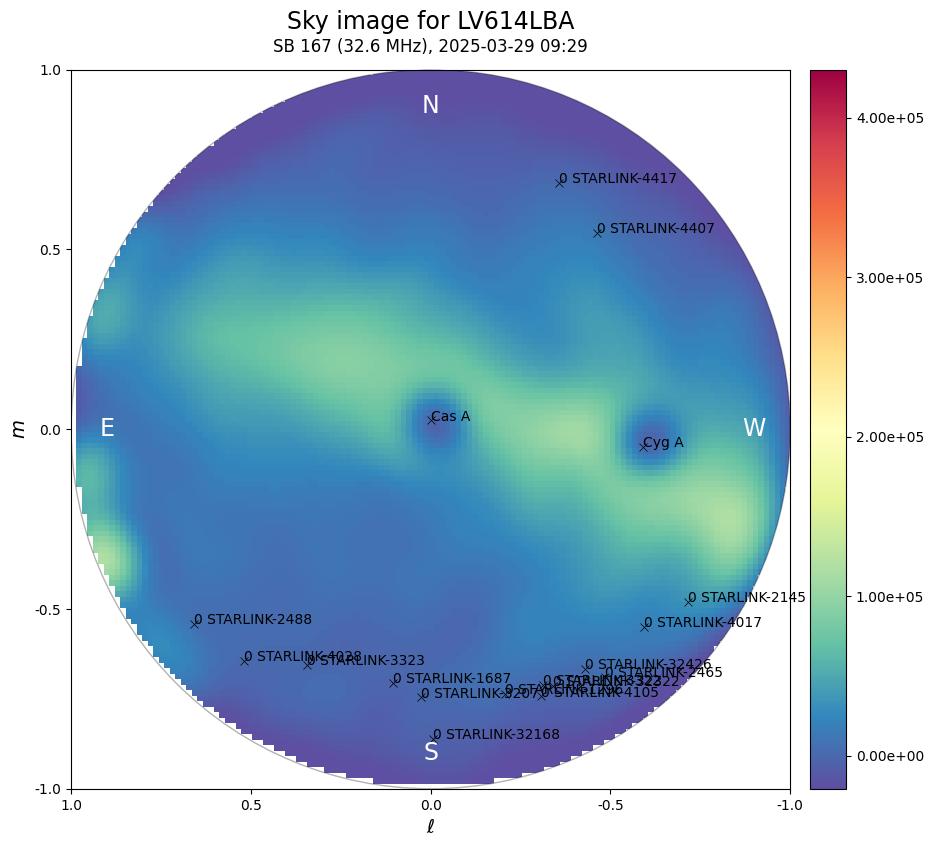

In [126]:
fig0 = make_sky_plot(img_subtracted, marked_all_lmn, title=f"Sky image for {station_name}",
                    subtitle=f"SB {subband} ({freq / 1e6:.1f} MHz), {str(obstime)[:16]}",
                   vmin=np.nanquantile(img_subtracted,0.05), vmax = 4.3e5);

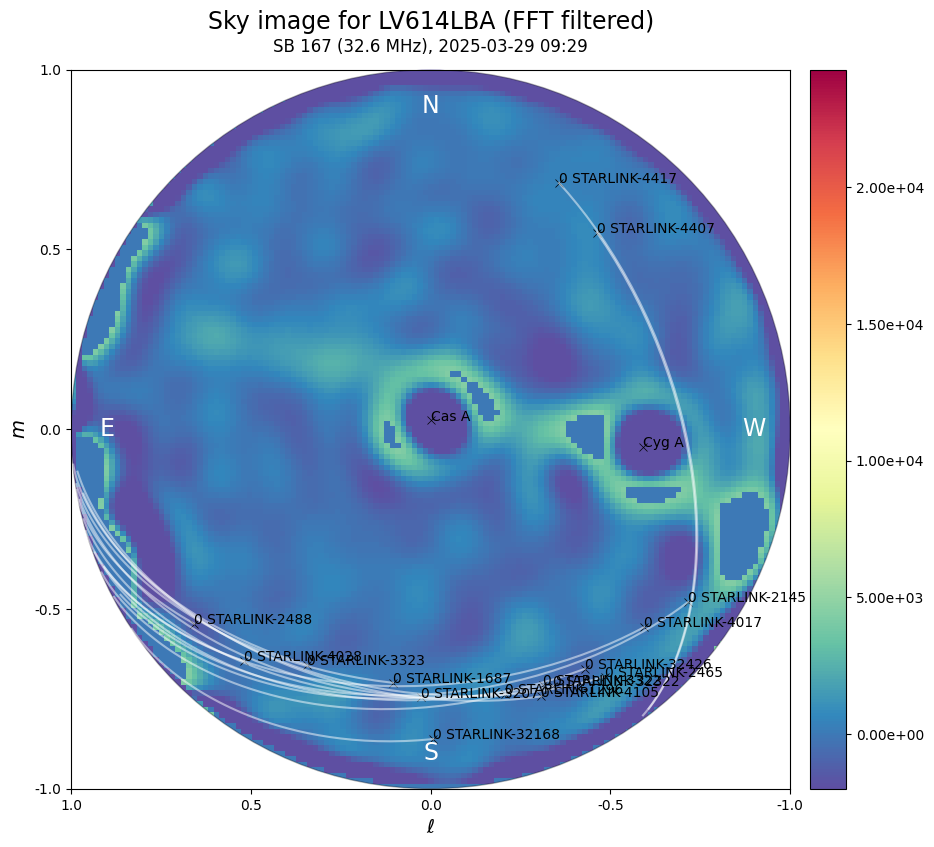

In [127]:
img_fftclean[img_fftclean > np.nanpercentile(img_fftclean, 95)] = np.nanmedian(img_fftclean)

########## WITH FFT FILTERING
fig_clean = make_sky_plot(img_fftclean, marked_all_lmn, title=f"Sky image for {station_name} (FFT filtered)",
                    subtitle=f"SB {subband} ({freq / 1e6:.1f} MHz), {str(obstime)[:16]}", 
                    vmin=-2e3, vmax=6*std_fftclean); #vmin = -std_fftclean, 0, ?????
for sat_name, (l, m, n) in marked_sats_traj_lmn.items():
    fig_clean.axes[0].plot(l, m, color='white', linestyle='-', alpha=0.5)

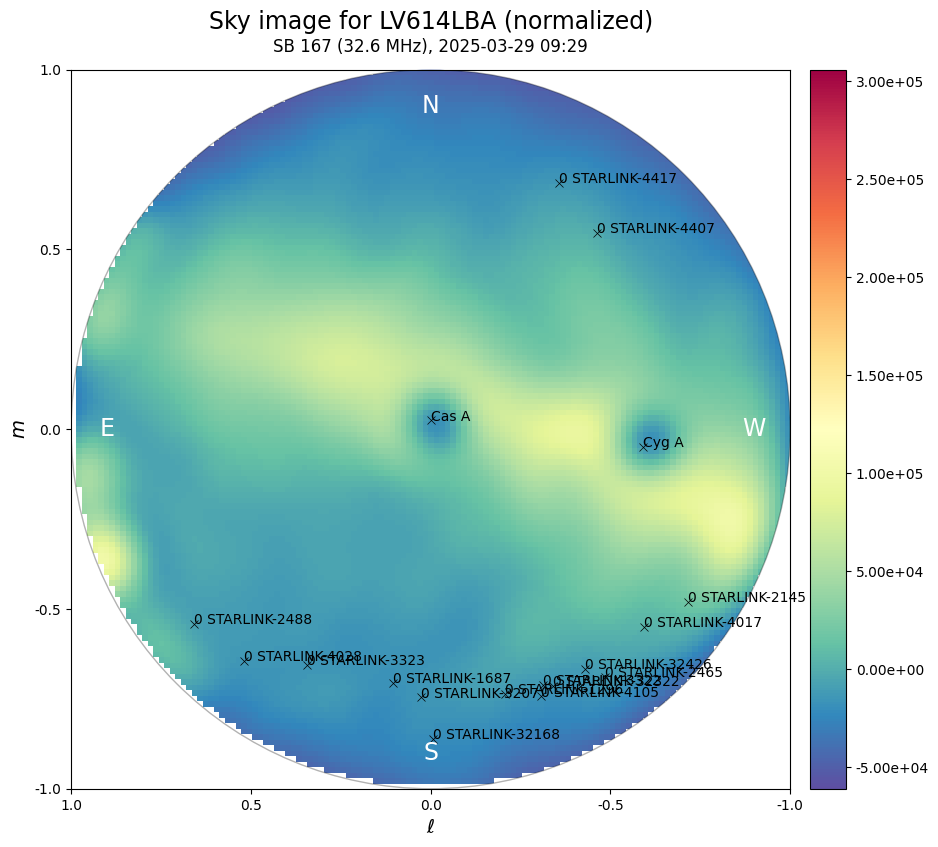

In [128]:
############# WITH NANMEDIAN
img_subtracted_normalized = img_subtracted - np.nanmedian(img_subtracted)
std_val = np.nanstd(img_subtracted_normalized)


fig2 = make_sky_plot(img_subtracted_normalized, marked_all_lmn, title=f"Sky image for {station_name} (normalized)",
                    subtitle=f"SB {subband} ({freq / 1e6:.1f} MHz), {str(obstime)[:16]}", 
                    vmin=-2*std_val, vmax=10*std_val);
# vmin=np.quantile(img_subtracted_normalized, 0.05)

########## WITH MEDIAN_FILTER
# fig3 = make_sky_plot(img_clean, marked_all_lmn, title=f"Sky image for {station_name} (median filter)",
#                    subtitle=f"SB {subband} ({freq / 1e6:.1f} MHz), {str(obstime)[:16]}", 
#                    vmin=-2*std_clean, vmax=10*std_clean);

########## WITH WAVELETS
# fig5 = make_sky_plot(img_wavelet, marked_all_lmn, title=f"Sky image for {station_name} (wavelet w/o aproximation)",
#                    subtitle=f"SB {subband} ({freq / 1e6:.1f} MHz), {str(obstime)[:16]}", 
#                    vmin=-2*std_wavelet, vmax=10*std_wavelet);

In [129]:
########-------------- NEAR FIELD
fig_clean.savefig(os.path.join('results', f'{fname}_sky_calibrated.png'), bbox_inches='tight', dpi=200)

In [130]:
plt.close(fig_clean)

In [131]:
npix_x, npix_y = int(ground_resolution * (extent[1] - extent[0])), int(ground_resolution * (extent[3] - extent[2]))

In [132]:
os.environ["NUMEXPR_NUM_THREADS"] = "3"

In [133]:
# Select a subset of visibilities, only the lower triangular part
baseline_indices = np.tril_indices(visibilities.shape[0])

In [134]:
visibilities_selection = visibilities_subtracted[baseline_indices]

In [135]:
%time img = nearfield_imager(visibilities_selection.flatten()[:,np.newaxis], \
                             np.array(baseline_indices).T, \
                             [freq], npix_x, npix_y, extent, station_xyz, height=height)
# Correct for taking only lower triangular part
img = np.real(2 * img)

CPU times: user 41.2 s, sys: 11.7 s, total: 52.9 s
Wall time: 16.2 s


In [136]:
import lofargeotiff

In [137]:
# Convert bottom left and upper right to PQR just for lofargeo
pmin, qmin, _ = pqr_to_xyz.T @ (np.array([extent[0], extent[2], 0]))
pmax, qmax, _ = pqr_to_xyz.T @ (np.array([extent[1], extent[3], 0]))
lon_center, lat_center, _ = lofargeotiff.pqr_to_longlatheight([0, 0, 0], station_name)
lon_min, lat_min, _ = lofargeotiff.pqr_to_longlatheight([pmin, qmin, 0], station_name)
lon_max, lat_max, _ = lofargeotiff.pqr_to_longlatheight([pmax, qmax, 0], station_name)

In [138]:
background_map = get_map(lon_min, lon_max, lat_min, lat_max, 5)

In [139]:
# Make colors semi-transparent in the lower 3/4 of the scale
cmap = cm.Spectral_r
cmap_with_alpha = cmap(np.arange(cmap.N))
cmap_with_alpha[:, -1] = np.clip(np.linspace(0, 1.5, cmap.N), 0., 1.)
cmap_with_alpha = ListedColormap(cmap_with_alpha)

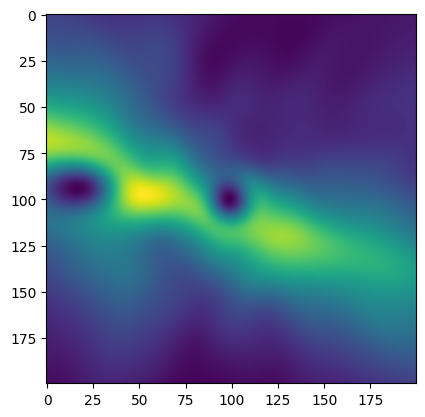

In [140]:
for sat in satellites:
    # get the satellite's position at time 't'
    geocentric = sat.at(t)
    
    # get geographic coordinates
    subpoint = geocentric.subpoint()
    sat_lat = subpoint.latitude.degrees
    sat_lon = subpoint.longitude.degrees
    
    # check if satellite is within map boundaries
    if (lon_min <= sat_lon <= lon_max) and (lat_min <= sat_lat <= lat_max):
        ax.plot(sat_lon, sat_lat, marker='x', color='white', markersize=8, zorder=10)
        ax.text(sat_lon + 0.05, sat_lat, f" {sat.name}", color='white', fontsize=9, zorder=10)
        
plt.imshow(img)

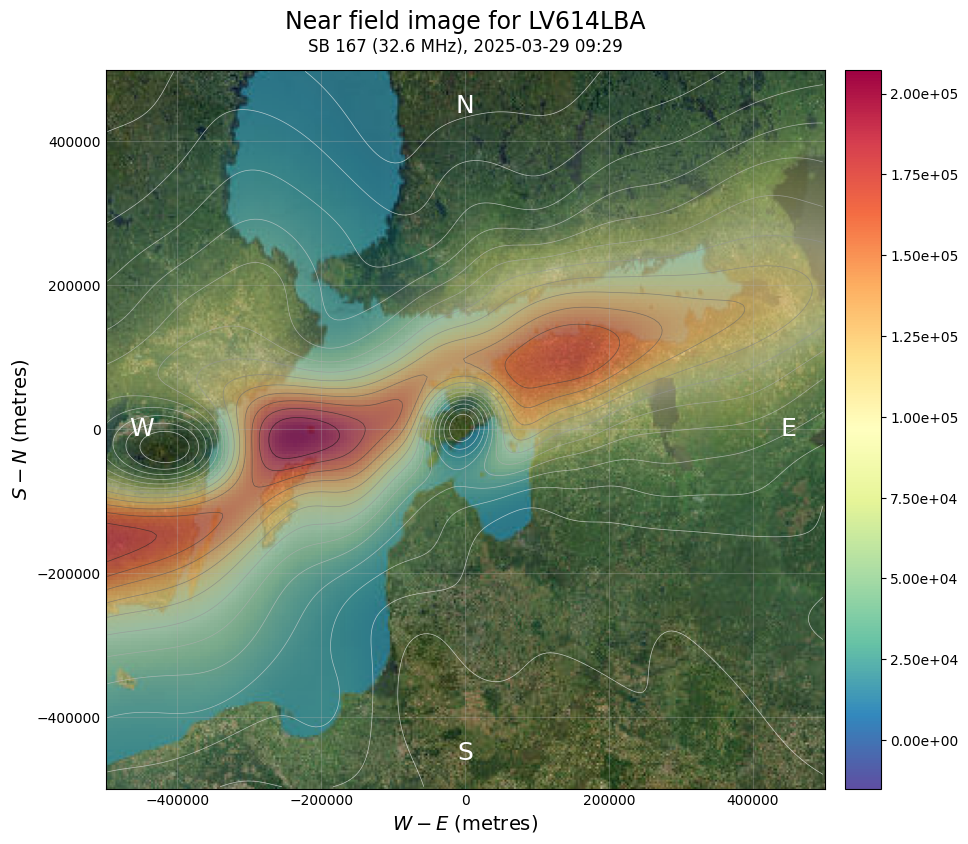

In [141]:
fig, folium_overlay = make_ground_plot(img, background_map, extent,
                                       title=f"Near field image for {station_name}",
                                       subtitle=f"SB {subband} ({freq / 1e6:.1f} MHz), {str(obstime)[:16]}",
                                       opacity=0.7)

In [142]:
maxpixel_ypix, maxpixel_xpix = np.unravel_index(np.argmax(img_filtered), img_filtered.shape)
maxpixel_x = np.interp(maxpixel_xpix, [0, npix_x], [extent[0], extent[1]])
maxpixel_y = np.interp(maxpixel_ypix, [0, npix_y], [extent[2], extent[3]])
[maxpixel_p, maxpixel_q, _] = pqr_to_xyz.T @ np.array([maxpixel_x, maxpixel_y, height])
maxpixel_lon, maxpixel_lat, _ = lofargeotiff.pqr_to_longlatheight([maxpixel_p, maxpixel_q], station_name)

In [143]:
# Show location of maximum if not at the image border
if 5 < maxpixel_xpix < npix_x - 5 and 5 < maxpixel_ypix < npix_y - 5:
    print(f"Maximum at {maxpixel_x:.0f}m east, {maxpixel_y:.0f}m north of station center (lat/long {maxpixel_lat:.5f}, {maxpixel_lon:.5f})")

Maximum at -305000m east, -305000m north of station center (lat/long 54.72749, 17.12628)


In [144]:
# Check total time to run
end1 = time.time()
print ('Time elapsed: %.2f s' % (end1-start1))

Time elapsed: 127.99 s


Export the near field image to GeoTIFF for archiving and viewing in other tools (QGIS).

In [145]:
obstime = datetime.datetime.strptime(obsdatestr + ":" + obstimestr, '%Y%m%d:%H%M%S')

In [146]:
tags = {"datafile": xst_filename,
        "generated_with": f"lofarimaging notebook",
        "subband": subband,
        "frequency": freq,
        "extent_xyz": extent,
        "height": height,
        "station": station_name,
        "pixels_per_metre": pixels_per_metre}
tags.update(calibration_info)
lofargeotiff.write_geotiff(img, f"results/{fname}_nearfield_calibrated.tiff",
                           (pmin, qmin), (pmax, qmax), stationname=station_name,
                           obsdate=obstime, tags=tags)

Overlay the near field image on a map.


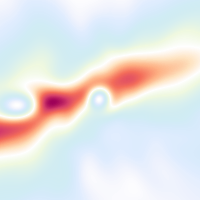

In [147]:
make_leaflet_map(folium_overlay, lon_center, lat_center, lon_min, lat_min, lon_max, lat_max)

In [148]:
#%pip install git+https://github.com/2baOrNot2ba/iLiSA.git
#%pip install git+https://github.com/2baOrNot2ba/dreamBeam.git